# Exercises 12

In [1]:
# Imports
from cycler import cycler

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Dense,
    Input,
    Flatten,
    Conv2D,
    MaxPooling2D,
    Dropout,
    Reshape,
)
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Nadam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import CategoricalAccuracy, Precision, Recall, F1Score
from tensorflow.keras.activations import relu
from tensorflow.random import set_seed
from tensorflow.keras.utils import to_categorical

import scienceplots

plt.style.use(["science", "ieee"])

colors = plt.cm.Set2.colors
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)

plt.rcParams["figure.dpi"] = 300

In [2]:
# set the seed for reproducibility
seed = 0

np.random.seed(seed)
set_seed(seed)

In [3]:
# load the MNIST dataset
from tensorflow.keras.datasets import mnist

img_shape = (28, 28, 1)
num_classes = 10

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"Training set: {x_train.shape}, {y_train.shape}")
print(f"Test set: {x_test.shape}, {y_test.shape}")

Training set: (60000, 28, 28), (60000,)
Test set: (10000, 28, 28), (10000,)


In [4]:
# preprocess data
labels = np.unique(y_train)
print(f"Labels: {labels}")

y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

# normalization
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print(f"Min: {x_train.min()}, Max: {x_train.max()}")

Labels: [0 1 2 3 4 5 6 7 8 9]
Min: 0.0, Max: 1.0


## Exercises 12.1

In [5]:
def create_DNN(opt, name):
    """Create a DNN model for MNIST classification."""
    model = Sequential(name=name)

    model.add(Input(shape=(28, 28, 1)))
    # instead of modifying the dataset, modify the model to accept the original shape of the data
    model.add(Reshape(target_shape=(784,)))

    model.add(Dense(100, activation=relu))
    model.add(Dropout(0.2))
    model.add(Dense(100, activation=relu))
    model.add(Dropout(0.2))
    model.add(Dense(50, activation=relu))

    model.add(Dense(10, activation="softmax"))

    model.compile(
        optimizer=opt,
        loss=CategoricalCrossentropy(),
        metrics=[CategoricalAccuracy(), Precision(), Recall(), F1Score()],
    )

    model.summary()

    return model

In [6]:
# Train the model with different optimizers and store the history for each optimizer
hist = []
models = []
opts = [SGD(), Adam(), RMSprop()]
names = ["SGD", "Adam", "RMSprop"]

for opt, name in zip(opts, names):
    model = create_DNN(opt, name)
    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_test, y_test),
        epochs=30,
        batch_size=128,
        verbose=1,
        shuffle=True,
    )

    hist.append(history)
    models.append(model)

Model: "SGD"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,160 (367.81 KB)

 Trainable params: 94,160 (367.81 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_2 (Reshape)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,160 (367.81 KB)

 Trainable params: 94,160 (367.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - categorical_accuracy: 0.8695 - f1_score: 0.8679 - loss: 0.4280 - precision_2: 0.9238 - recall_2: 0.8154 - val_categorical_accuracy: 0.9494 - val_f1_score: 0.9487 - val_loss: 0.1652 - val_precision_2: 0.9592 - val_recall_2: 0.9400
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - categorical_accuracy: 0.9429 - f1_score: 0.9423 - loss: 0.1923 - precision_2: 0.9548 - recall_2: 0.9321 - val_categorical_accuracy: 0.9618 - val_f1_score: 0.9613 - val_loss: 0.1195 - val_precision_2: 0.9697 - val_recall_2: 0.9571
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - categorical_accuracy: 0.9541 - f1_score: 0.9536 - loss: 0.1523 - precision_2: 0.9636 - recall_2: 0.9462 - val_categorical_accuracy: 0.9687 - val_f1_score: 0.9684 - val_loss: 0.1037 - val_precision_2: 0.9728 - val_recall_2: 0.9639
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - categorical_accuracy: 0.9607 - f1_score: 0.9604 - loss: 0.1292 - precision_2: 0.9673 - recall_

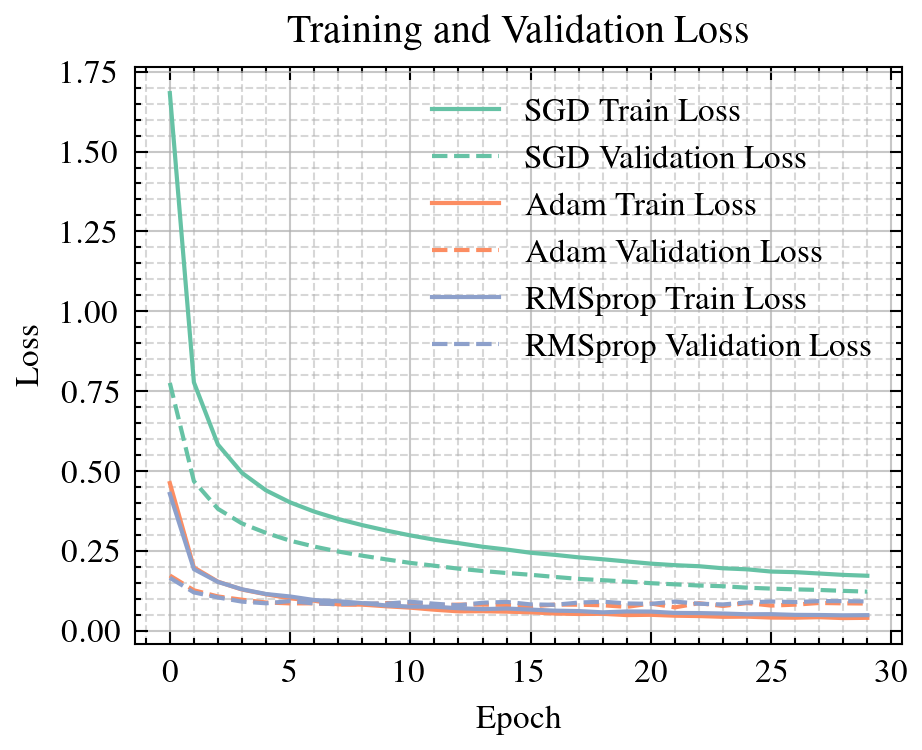

In [7]:
# plot training and validation loss for each optimizer
for history, name in zip(hist, names):
    lines = plt.plot(history.history["loss"], label=f"{name} Train Loss")
    plt.plot(
        history.history["val_loss"],
        label=f"{name} Validation Loss",
        color=lines[0].get_color(),
        linestyle="--",
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True, which="major", alpha=0.7)
plt.grid(True, which="minor", linestyle="--", alpha=0.5)

plt.show()

We can see that SGD optimizer is a bit slower than Adam and RMSprop, and it will probably need a few more epochs before convergence.

Overall all 3 optimizer get to a loss near 0.1. Also watching the validation accuracy we can see that Adam and RMSprop come near 98% accuracy, while SGD has 96%, considering that the DNN is not able to extract local features it is still quite good in all three cases. 

## Exercises 12.2

We now want to investigate how the CNN behaves, since it is able to keep the local features of images.

In [8]:
def create_CNN(opt, name):
    """Create a CNN model for MNIST classification."""
    model = Sequential(name=name)

    model.add(Input(shape=(28, 28, 1)))

    model.add(Conv2D(16, kernel_size=3, padding="same", activation=relu))
    model.add(MaxPooling2D(pool_size=2))
    model.add(Dropout(0.25))

    model.add(Conv2D(32, kernel_size=3, padding="same", activation=relu))
    model.add(MaxPooling2D(pool_size=2))
    model.add(Dropout(0.25))

    model.add(Conv2D(64, kernel_size=3, padding="same", activation=relu))
    model.add(MaxPooling2D(pool_size=2))
    model.add(Dropout(0.25))

    model.add(Flatten())

    model.add(Dense(32, activation=relu))

    model.add(Dense(10, activation="softmax"))

    model.compile(
        optimizer=opt,
        loss=CategoricalCrossentropy(),
        metrics=[CategoricalAccuracy(), Precision(), Recall(), F1Score()],
    )

    model.summary()

    return model

In [9]:
# Train the CNN model with different optimizers and store the history for each optimizer
hist = []
models_cnn = []
names = ["SGD", "Adam", "RMSprop"]
opts = [SGD(), Adam(), RMSprop()]

for opt, name in zip(opts, names):
    model = create_CNN(opt, name)
    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_test, y_test),
        epochs=30,
        batch_size=64,
        verbose=1,
        shuffle=True,
    )

    hist.append(history)
    models_cnn.append(model)

Model: "SGD"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,090 (164.41 KB)

 Trainable params: 42,090 (164.41 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,090 (164.41 KB)

 Trainable params: 42,090 (164.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - categorical_accuracy: 0.8860 - f1_score: 0.8848 - loss: 0.3524 - precision_5: 0.9406 - recall_5: 0.8506 - val_categorical_accuracy: 0.9795 - val_f1_score: 0.9794 - val_loss: 0.0682 - val_precision_5: 0.9837 - val_recall_5: 0.9766
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - categorical_accuracy: 0.9674 - f1_score: 0.9671 - loss: 0.1025 - precision_5: 0.9724 - recall_5: 0.9639 - val_categorical_accuracy: 0.9862 - val_f1_score: 0.9862 - val_loss: 0.0440 - val_precision_5: 0.9878 - val_recall_5: 0.9852
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - categorical_accuracy: 0.9758 - f1_score: 0.9757 - loss: 0.0784 - precision_5: 0.9790 - recall_5: 0.9737 - val_categorical_accuracy: 0.9893 - val_f1_score: 0.9892 - val_loss: 0.0320 - val_precision_5: 0.9901 - val_recall_5: 0.9885
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - categorical_accuracy: 0.9797 - f1_score: 0.9796 - loss: 0.0648 - precision_5: 0.9820 - 

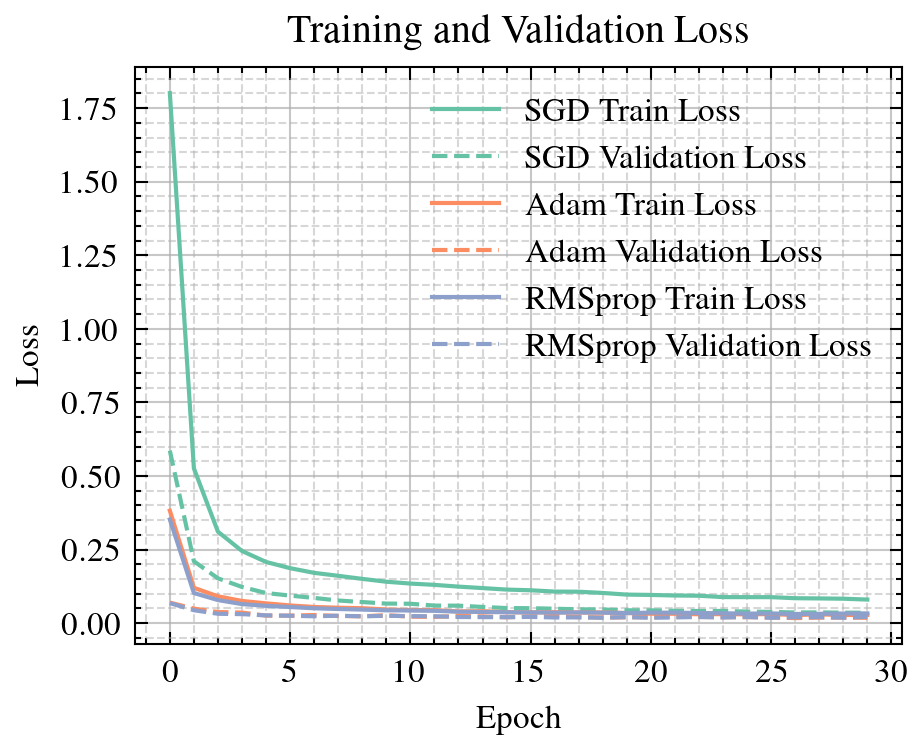

In [10]:
# Plot training and validation loss for each optimizer
for history, name in zip(hist, names):
    lines = plt.plot(history.history["loss"], label=f"{name} Train Loss")
    plt.plot(
        history.history["val_loss"],
        label=f"{name} Validation Loss",
        color=lines[0].get_color(),
        linestyle="--",
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True, which="major", alpha=0.7)
plt.grid(True, which="minor", linestyle="--", alpha=0.5)

plt.show()

Like before SGD is still slower than Adam/RMSprop, but all 3 of them reach a lower loss $\sim 0.025$, which is much better than DNN.

Also the accuracy is also better in all 3 cases we come near a 99% accuracy of evaluation.

We also have to note that training a CNN is slower than training the DNN, even if the parameters are less, thats due to the higher complexity of convolution and pooling layer.

## Exercise 12.3

We can try using our trained models to predict my handwritten digits.

I will show a DNN prediction and a CNN prediction both models using the Adam optimizer.

In [11]:
# Directory containing digit images
digit_dir = "./data/"

# Load all digit images
digits_data = {}
for digit in range(10):
    digit_filename = Path(digit_dir) / f"{digit}.png"

    try:
        digit_in = Image.open(digit_filename).convert("L")

        digits_data[digit] = np.array(digit_in) / 255

    except FileNotFoundError:
        print(f"Warning: {digit_filename} not found")

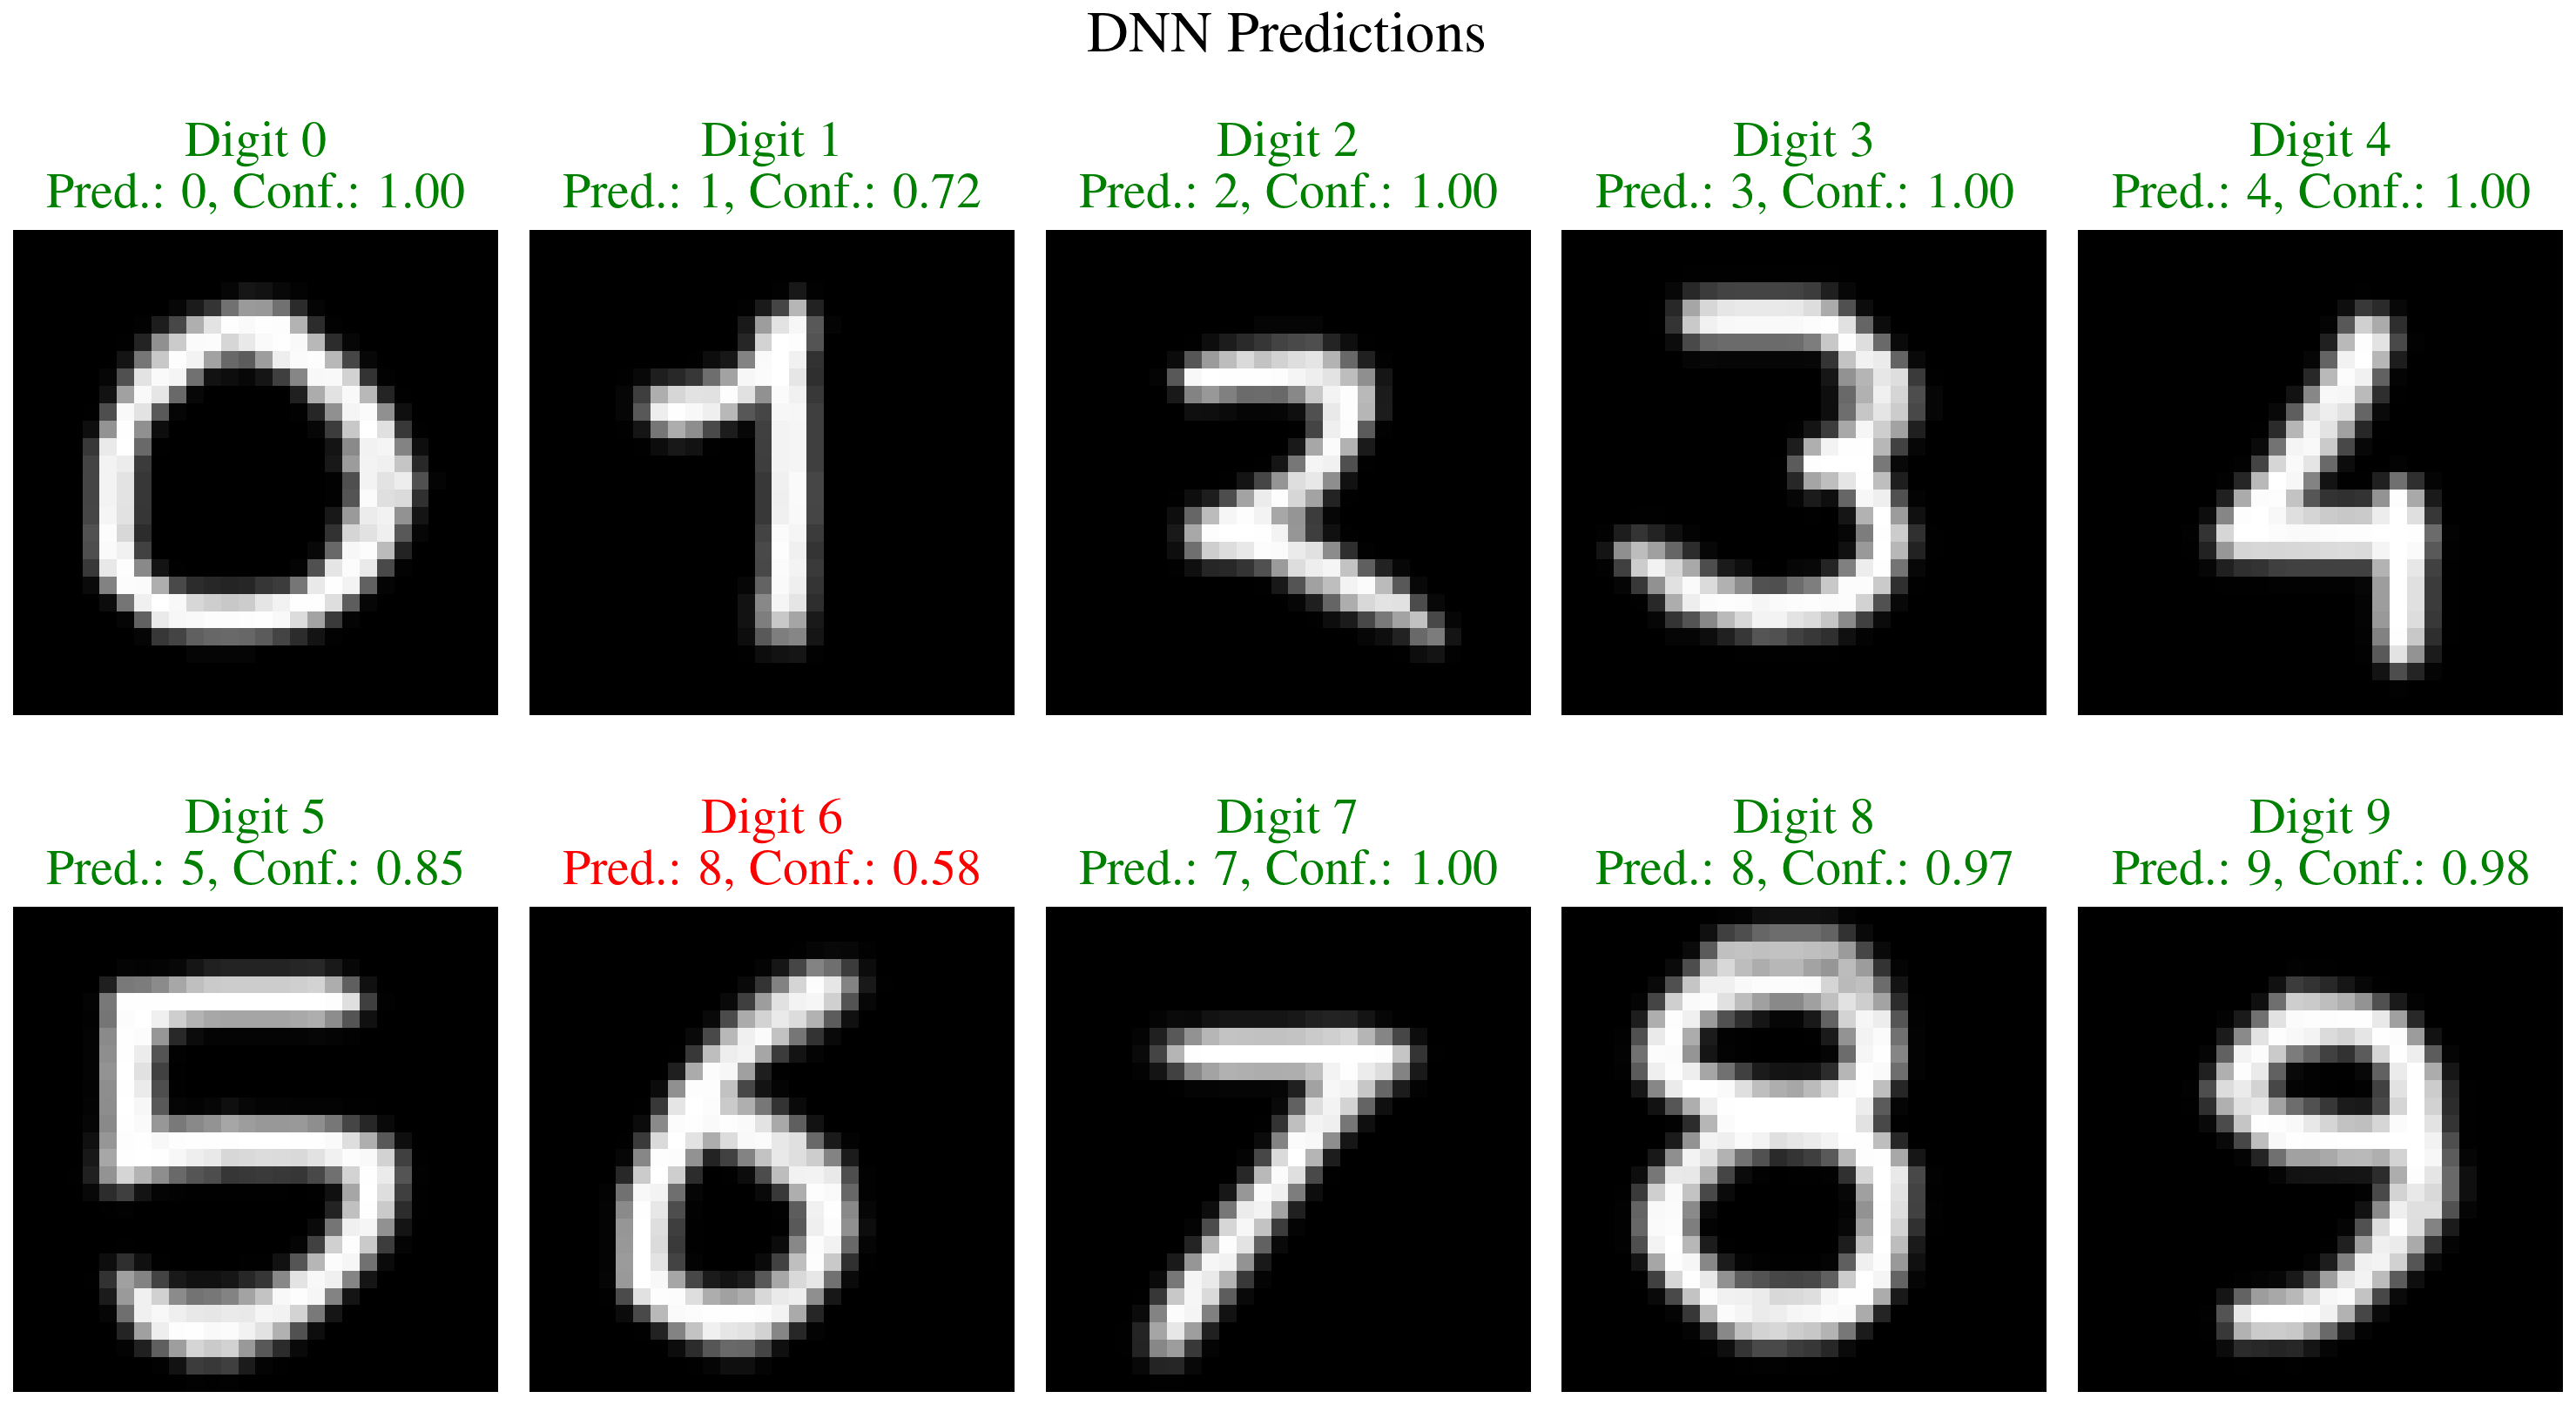

In [12]:
# DNN model for predictions
# Display all digits in a single figure and make predictions
fig, axes = plt.subplots(2, 5, figsize=(10, 6))
axes = axes.flatten()

for digit in range(10):
    data = digits_data[digit]

    axes[digit].imshow(data, cmap="gray")

    data = data.reshape(1, 28, 28, 1)
    y_pred = models[1].predict(data, verbose=0)
    color = "green" if np.argmax(y_pred) == digit else "red"

    axes[digit].set_title(
        f"Digit {digit}\nPred.: {np.argmax(y_pred)}, Conf.: {np.max(y_pred):.2f}",
        fontsize=14,
        color=color,
    )

    axes[digit].axis("off")

plt.suptitle("DNN Predictions", fontsize=16)

plt.tight_layout()
plt.show()

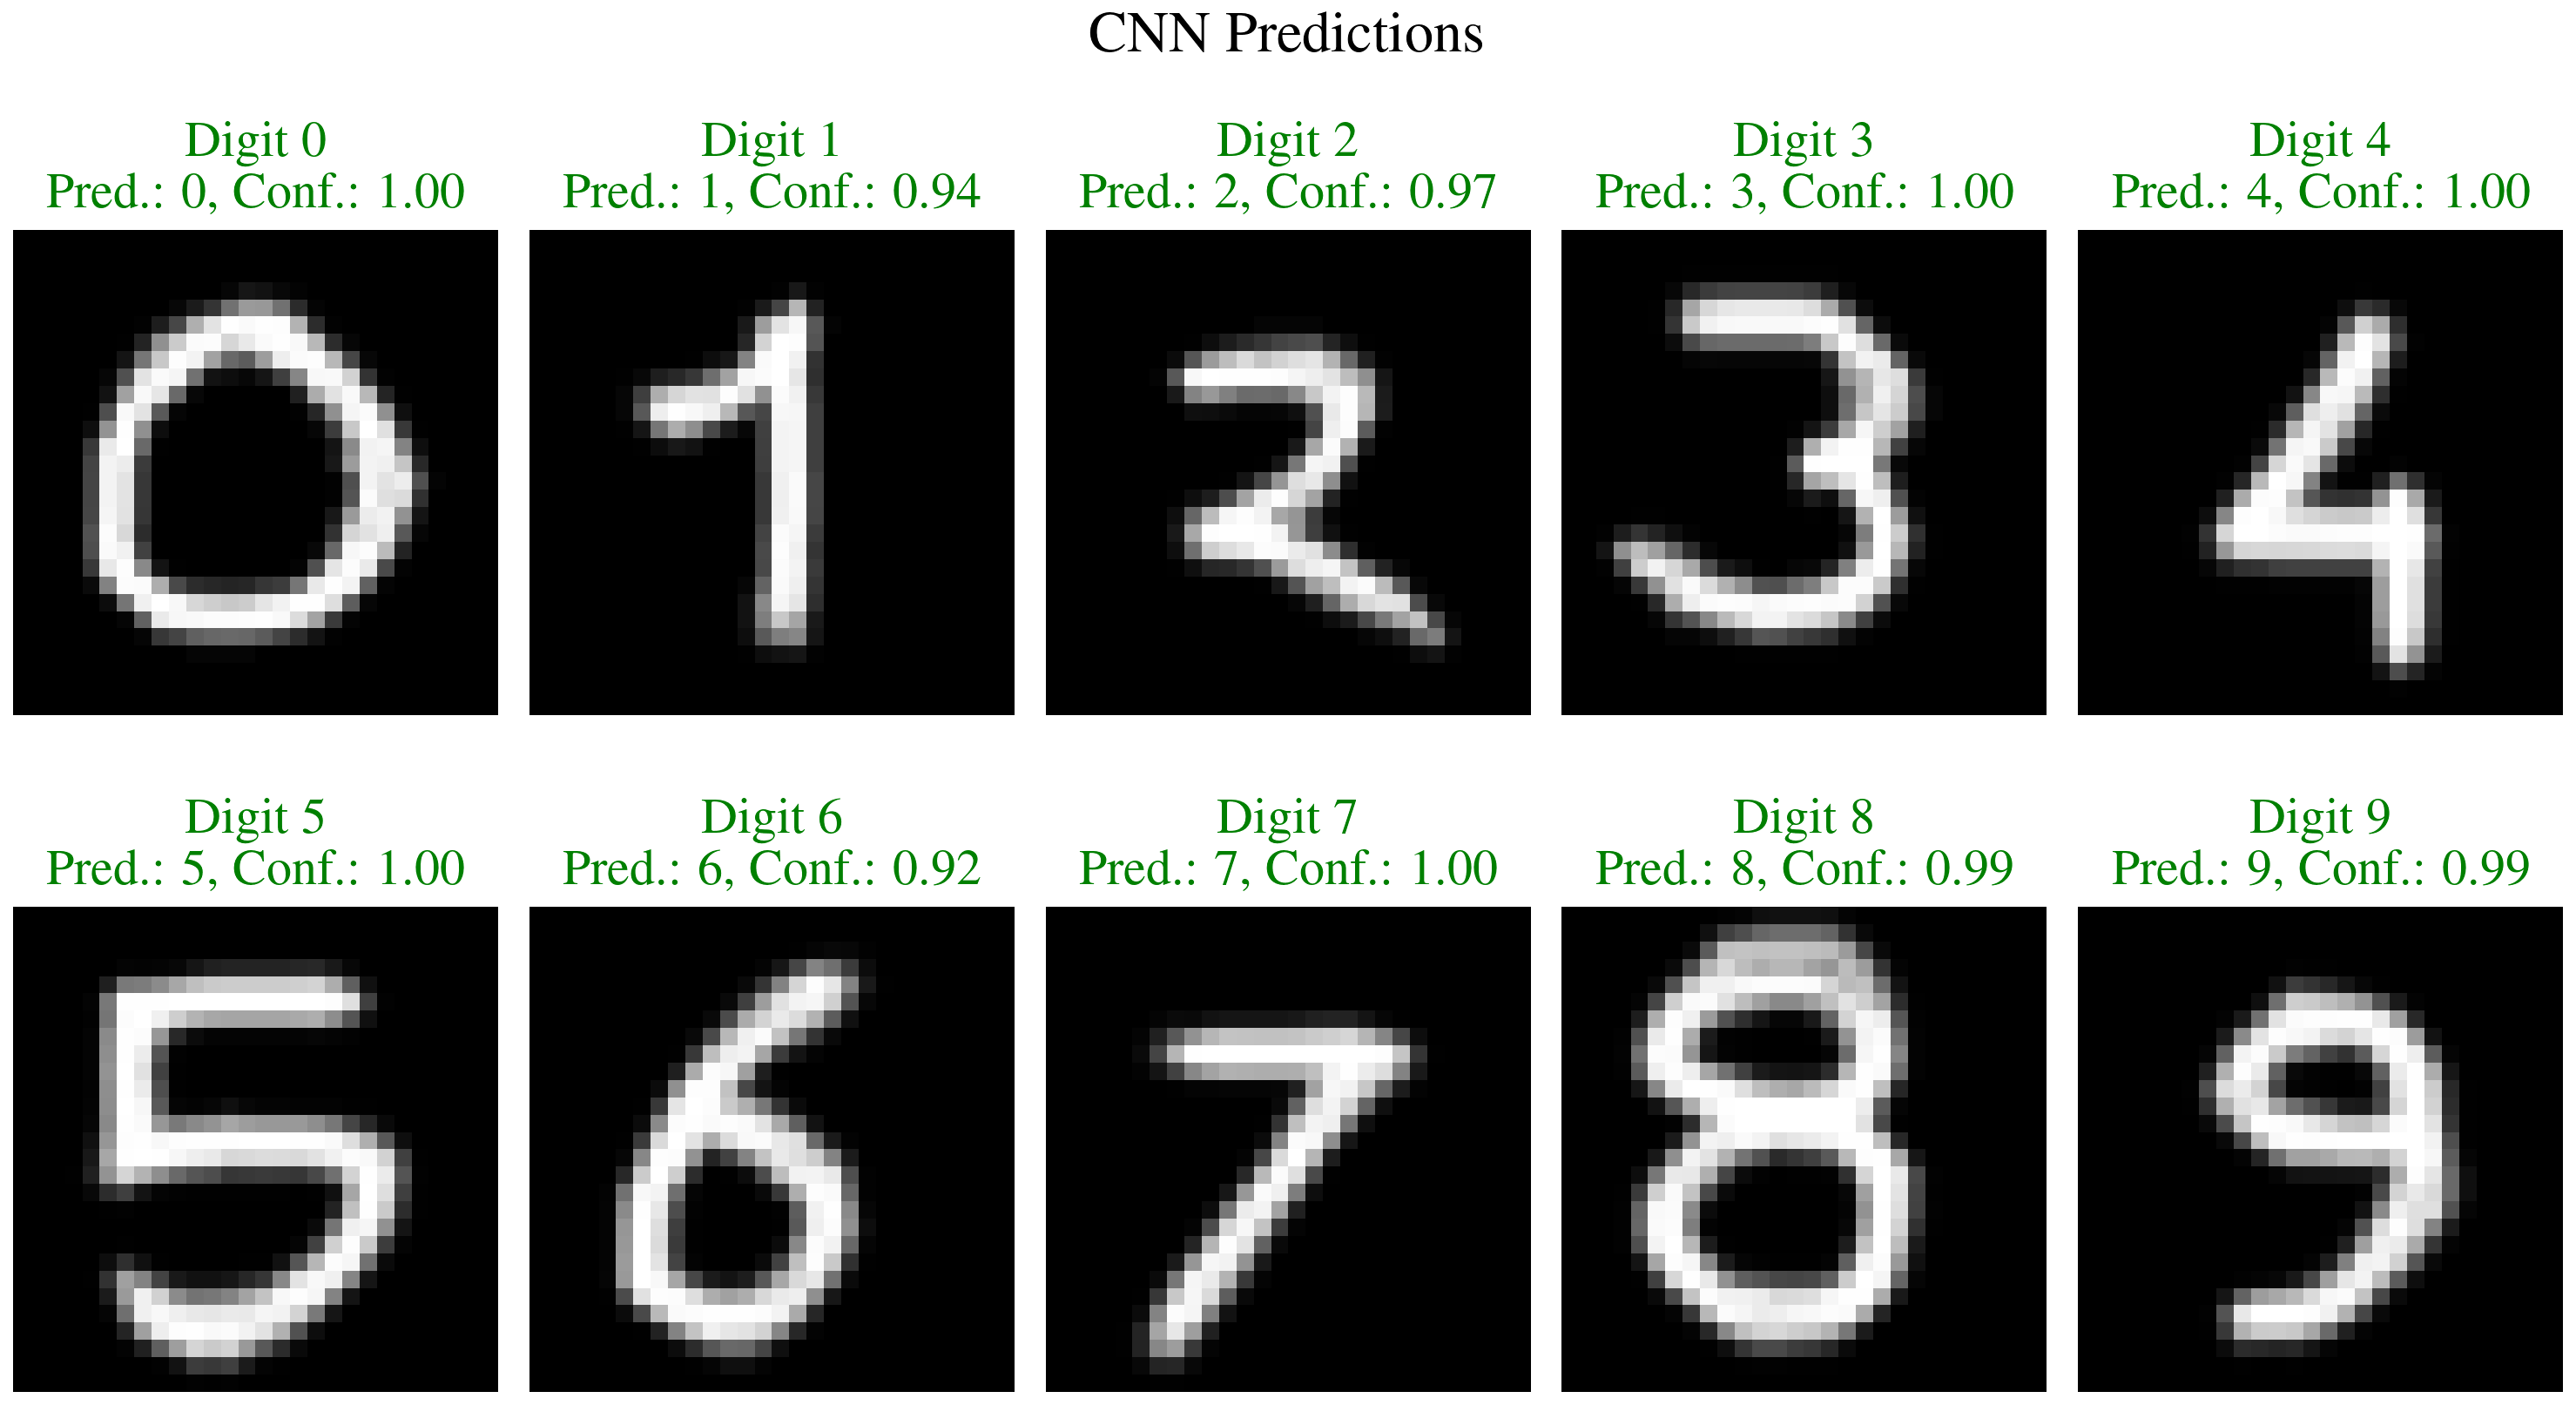

In [14]:
# CNN model for predictions
# Display all digits in a single figure and make predictions
fig, axes = plt.subplots(2, 5, figsize=(10, 6))
axes = axes.flatten()

for digit in range(10):
    data = digits_data[digit]

    axes[digit].imshow(data, cmap="gray")

    data = data.reshape(1, 28, 28, 1)
    y_pred = models_cnn[1].predict(data, verbose=0)
    color = "green" if np.argmax(y_pred) == digit else "red"

    axes[digit].set_title(
        f"Digit {digit}\nPred.: {np.argmax(y_pred)}, Conf.: {np.max(y_pred):.2f}",
        fontsize=14,
        color=color,
    )

    axes[digit].axis("off")

plt.suptitle("CNN Predictions", fontsize=16)
plt.tight_layout()
plt.show()

By using my numbers to make predictions we can see if the model can generalize to data not present in the dataset.

It is worth noting that:
- The model prediction is only as good as am I writing the numbers similar to the ones in the dataset.
- We cannot make a statistic on only these numbers but we would need a lot more of them to actually evaluate quantitatively the goodness of the model.